<a href="https://colab.research.google.com/github/hasinduwelikala/northstar-databases-analytics/blob/main/02_R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
install.packages("ggplot2")
install.packages("dplyr")
install.packages("corrplot")
install.packages("ggcorrplot")

library(ggplot2)
library(dplyr)
library(corrplot)
library(ggcorrplot)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [6]:
base_url <- "https://raw.githubusercontent.com/hasinduwelikala/northstar-databases-analytics/main/data/"

files <- c("orders.csv", "deliveries.csv", "hubs.csv",
           "customers.csv", "complaints.csv", "drivers.csv",
           "vehicles.csv", "incidents.csv", "app_events.csv",
           "data_dictionary.csv")

for (f in files) {
  download.file(paste0(base_url, f), destfile = f, quiet = TRUE)
}
cat("All files downloaded successfully.\n")

orders     <- read.csv("orders.csv",     stringsAsFactors = FALSE, na.strings = "")
deliveries <- read.csv("deliveries.csv", stringsAsFactors = FALSE, na.strings = "")
hubs       <- read.csv("hubs.csv",       stringsAsFactors = FALSE, na.strings = "")
customers  <- read.csv("customers.csv",  stringsAsFactors = FALSE, na.strings = "")
complaints <- read.csv("complaints.csv", stringsAsFactors = FALSE, na.strings = "")
drivers    <- read.csv("drivers.csv", stringsAsFactors = FALSE, na.strings = "")
vehicles   <- read.csv("vehicles.csv", stringsAsFactors = FALSE, na.strings = "")
incidents  <- read.csv("incidents.csv", stringsAsFactors = FALSE, na.strings = "")
app_events <- read.csv("app_events.csv", stringsAsFactors = FALSE, na.strings = "")
data_dictionary <- read.csv("data_dictionary.csv", stringsAsFactors = FALSE, na.strings = "")

All files downloaded successfully.


In [7]:
standardise_zone <- function(x) {
  x <- trimws(x)
  x <- gsub("(?i)^ctr$",       "Central",   x, perl = TRUE)
  x <- gsub("(?i)^riverside$", "Riverside", x, perl = TRUE)
  x <- gsub("(?i)^airport$",   "Airport",   x, perl = TRUE)
  x <- gsub("(?i)^central$",   "Central",   x, perl = TRUE)
  x <- gsub("(?i)^north$",     "North",     x, perl = TRUE)
  x <- gsub("(?i)^south$",     "South",     x, perl = TRUE)
  x <- gsub("(?i)^east$",      "East",      x, perl = TRUE)
  x <- gsub("(?i)^west$",      "West",      x, perl = TRUE)
  return(x)
}

drivers$base_zone      <- standardise_zone(drivers$base_zone)
vehicles$assigned_zone <- standardise_zone(vehicles$assigned_zone)
customers$home_zone    <- standardise_zone(customers$home_zone)

In [8]:
training_vec <- drivers$training_score
training_vec[is.na(training_vec)] <- median(training_vec, na.rm = TRUE)
drivers$training_score <- training_vec

battery_vec <- vehicles$battery_health_pct
battery_vec[is.na(battery_vec)] <- median(battery_vec, na.rm = TRUE)
vehicles$battery_health_pct <- battery_vec

hours_vec <- incidents$resolved_hours
hours_vec[is.na(hours_vec)] <- median(hours_vec, na.rm = TRUE)
incidents$resolved_hours <- hours_vec

cat("NAs after imputation — training:", sum(is.na(drivers$training_score)),
    "| battery:", sum(is.na(vehicles$battery_health_pct)),
    "| hours:", sum(is.na(incidents$resolved_hours)), "\n")


NAs after imputation — training: 0 | battery: 0 | hours: 0 



── Analysis 1: Driver workforce descriptive statistics ───────────────
=== Training score ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  40.60   68.55   75.20   74.91   82.75   99.00       7 
=== Driver rating ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.150   3.905   4.175   4.172   4.478   5.000 
=== Years experience ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   5.000   8.500   8.224  11.750  15.000 

SD — training_score:   11.21 
SD — driver_rating:    0.41 
SD — years_experience: 4.11 

IQR — training_score:   14.2 
IQR — driver_rating:    0.5725 
IQR — years_experience: 6.75 

Drivers by employment type:

Contract FullTime PartTime 
      20      110       40 

Drivers by shift preference:

 Evening Flexible  Morning    Night 
      40       37       60       33 

Interpretation — Analysis 1:
Mean driver rating: 4.17 with SD: 0.41 
The narrow SD (0.41) and high mean (4.17/5) suggests most drivers perform consistently well.
The violin p

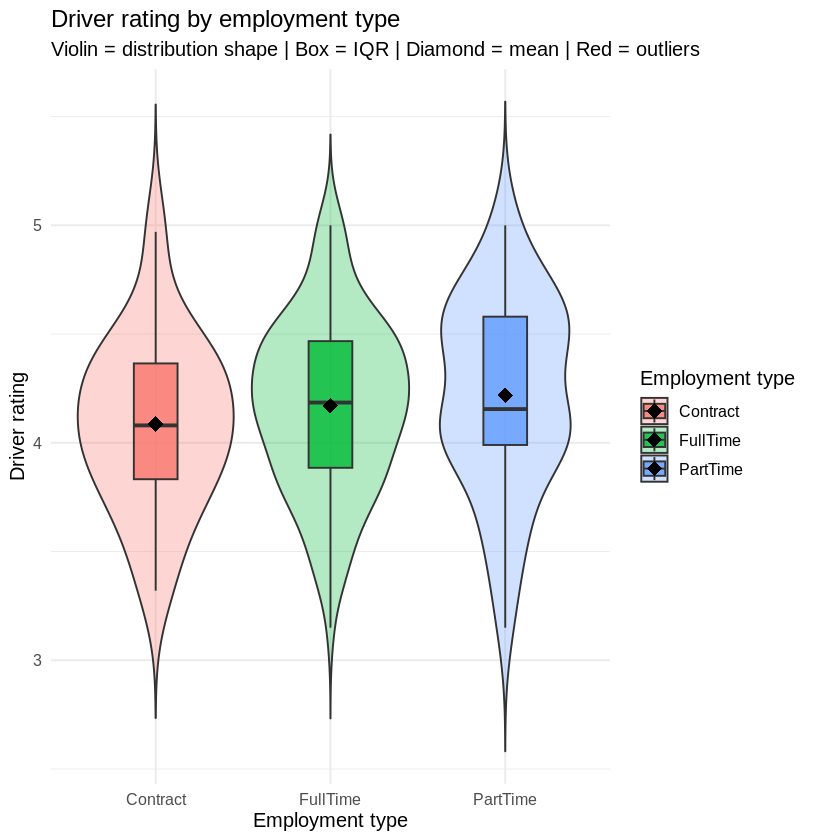

In [12]:
cat("\n── Analysis 1: Driver workforce descriptive statistics ───────────────\n")

cat("=== Training score ===\n");  print(summary(drivers$training_score))
cat("=== Driver rating ===\n");   print(summary(drivers$driver_rating))
cat("=== Years experience ===\n");print(summary(drivers$years_experience))

cat("\nSD — training_score:  ", round(sd(drivers$training_score, na.rm = TRUE),  2), "\n")
cat("SD — driver_rating:   ", round(sd(drivers$driver_rating),    2), "\n")
cat("SD — years_experience:", round(sd(drivers$years_experience), 2), "\n")

cat("\nIQR — training_score:  ", IQR(drivers$training_score, na.rm = TRUE),  "\n")
cat("IQR — driver_rating:   ", IQR(drivers$driver_rating),    "\n")
cat("IQR — years_experience:", IQR(drivers$years_experience), "\n")

cat("\nDrivers by employment type:\n"); print(table(drivers$employment_type))
cat("\nDrivers by shift preference:\n"); print(table(drivers$shift_preference))


ggplot(drivers, aes(x = employment_type, y = driver_rating, fill = employment_type)) +
  geom_violin(alpha = 0.3, trim = FALSE) +
  geom_boxplot(width = 0.25, alpha = 0.8, outlier.colour = "red", outlier.size = 2) +
  stat_summary(fun = mean, geom = "point", shape = 18, size = 4, colour = "black") +
  labs(
    title    = "Driver rating by employment type",
    subtitle = "Violin = distribution shape | Box = IQR | Diamond = mean | Red = outliers",
    x        = "Employment type", y = "Driver rating", fill = "Employment type"
  ) +
  theme_minimal(base_size = 12)

cat("\nInterpretation — Analysis 1:\n")
cat("Mean driver rating:", round(mean(drivers$driver_rating), 2),
    "with SD:", round(sd(drivers$driver_rating), 2), "\n")
cat("The narrow SD (0.41) and high mean (4.17/5) suggests most drivers",
    "perform consistently well.\n")
cat("The violin plot reveals whether any employment group has a bimodal",
    "distribution, indicating a split between high and low performers.\n")


── Analysis 2: Correlation — training score vs driver rating ──────────

	Pearson's product-moment correlation

data:  drivers$training_score and drivers$driver_rating
t = -0.88848, df = 161, p-value = 0.3756
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.22119671  0.08477949
sample estimates:
        cor 
-0.06985133 


Pearson r = -0.07
95% CI:   [ -0.221 , 0.085 ]
p-value   = 0.3756 
Correlation strength: weak 

Years experience vs driver rating — r = 0.063 | p = 0.4156 


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 7 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”



Interpretation:
A significant positive r means NorthStar should prioritise training as a lever for improving service quality.
The confidence interval shows the range of plausible true correlations.


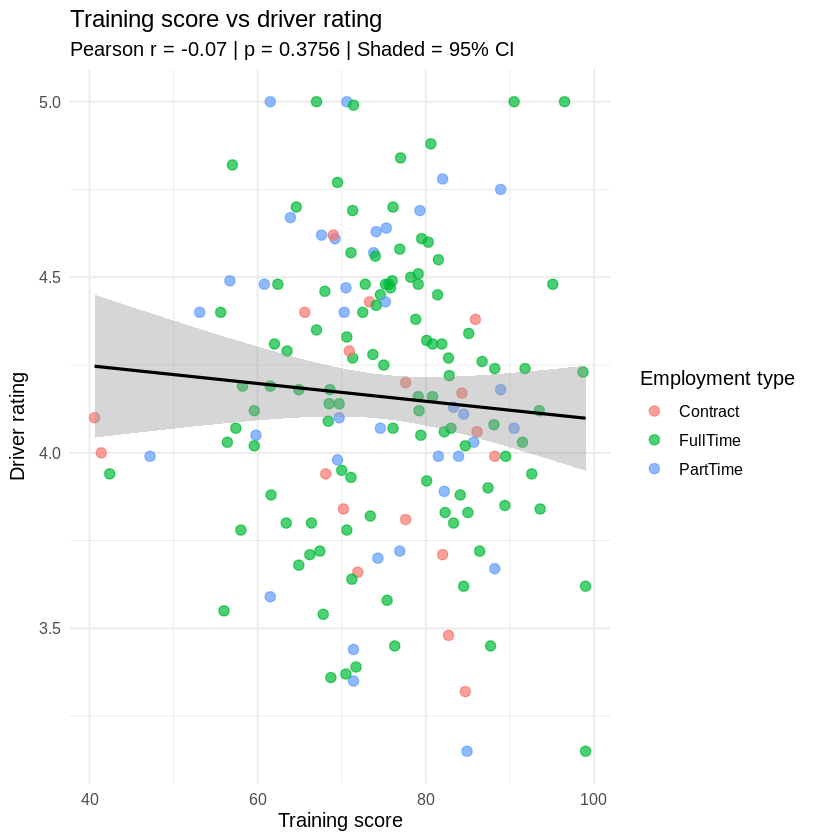

In [13]:
cat("\n── Analysis 2: Correlation — training score vs driver rating ──────────\n")

cor_train_rating <- cor.test(drivers$training_score,
                             drivers$driver_rating, method = "pearson")
print(cor_train_rating)

cat("\nPearson r =", round(cor_train_rating$estimate, 3))
cat("\n95% CI:   [", round(cor_train_rating$conf.int[1], 3), ",",
                     round(cor_train_rating$conf.int[2], 3), "]")
cat("\np-value   =", round(cor_train_rating$p.value, 4), "\n")

r  <- abs(cor_train_rating$estimate)
strength <- ifelse(r >= 0.7, "strong", ifelse(r >= 0.4, "moderate", "weak"))
cat("Correlation strength:", strength, "\n")

cor_exp_rating <- cor.test(drivers$years_experience,
                           drivers$driver_rating, method = "pearson")
cat("\nYears experience vs driver rating — r =",
    round(cor_exp_rating$estimate, 3),
    "| p =", round(cor_exp_rating$p.value, 4), "\n")

ggplot(drivers, aes(x = training_score, y = driver_rating)) +
  geom_point(aes(colour = employment_type), alpha = 0.7, size = 2.5) +
  geom_smooth(method = "lm", se = TRUE, colour = "black", linewidth = 0.9) +
  labs(title    = "Training score vs driver rating",
       subtitle = paste0("Pearson r = ", round(cor_train_rating$estimate, 3),
                         " | p = ", round(cor_train_rating$p.value, 4),
                         " | Shaded = 95% CI"),
       x = "Training score", y = "Driver rating", colour = "Employment type") +
  theme_minimal(base_size = 12)

cat("\nInterpretation:\n")
cat("A significant positive r means NorthStar should prioritise training",
    "as a lever for improving service quality.\n")
cat("The confidence interval shows the range of plausible true correlations.\n")


── Analysis 3: Vehicle battery health ─────────────────────────────────
Battery risk distribution:

    High Risk (<40%) Medium Risk (40-70%)       Healthy (>70%) 
                   0                   35                   85 

Percentage breakdown:

    High Risk (<40%) Medium Risk (40-70%)       Healthy (>70%) 
                 0.0                 29.2                 70.8 

Mean battery health by type:
CargoVan   Diesel       EV   Hybrid 
    73.4     70.6     81.9     76.9 

SD battery health by type:
CargoVan   Diesel       EV   Hybrid 
   11.66    12.77    10.12    13.81 

T-test — EV vs non-EV battery health:

	Welch Two Sample t-test

data:  ev_battery and non_ev_battery
t = 3.7441, df = 104.59, p-value = 0.0002963
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
  3.744157 12.174961
sample estimates:
mean of x mean of y 
 81.93488  73.97532 



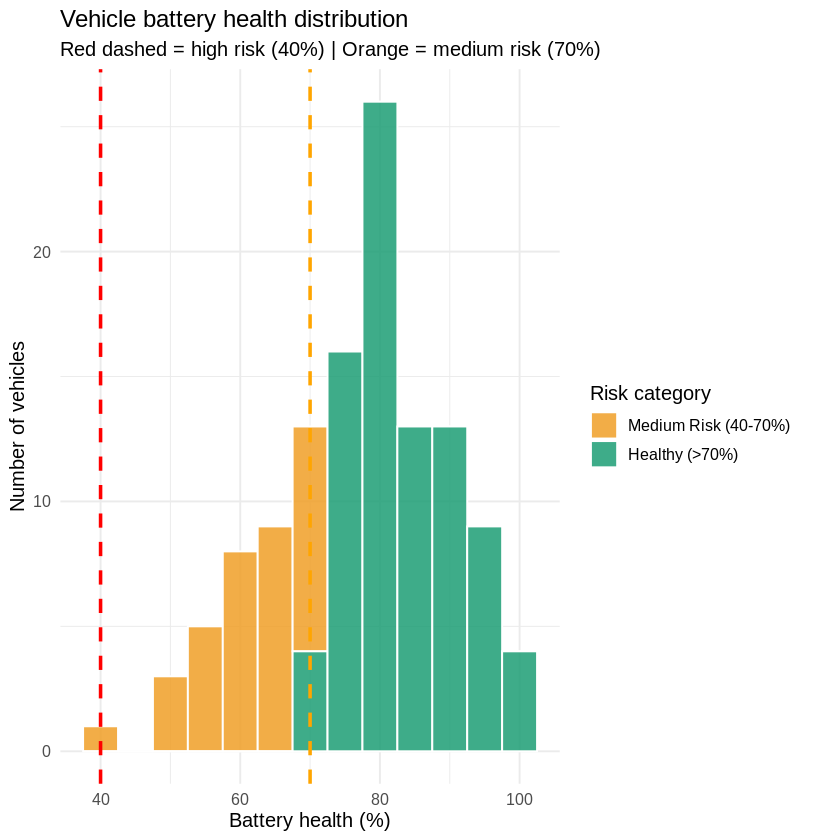


Interpretation:
prop.table() shows the percentage of fleet at each risk level.
If the t-test p < 0.05, EV vehicles have significantly different battery health — NorthStar needs a vehicle-type-specific maintenance policy.


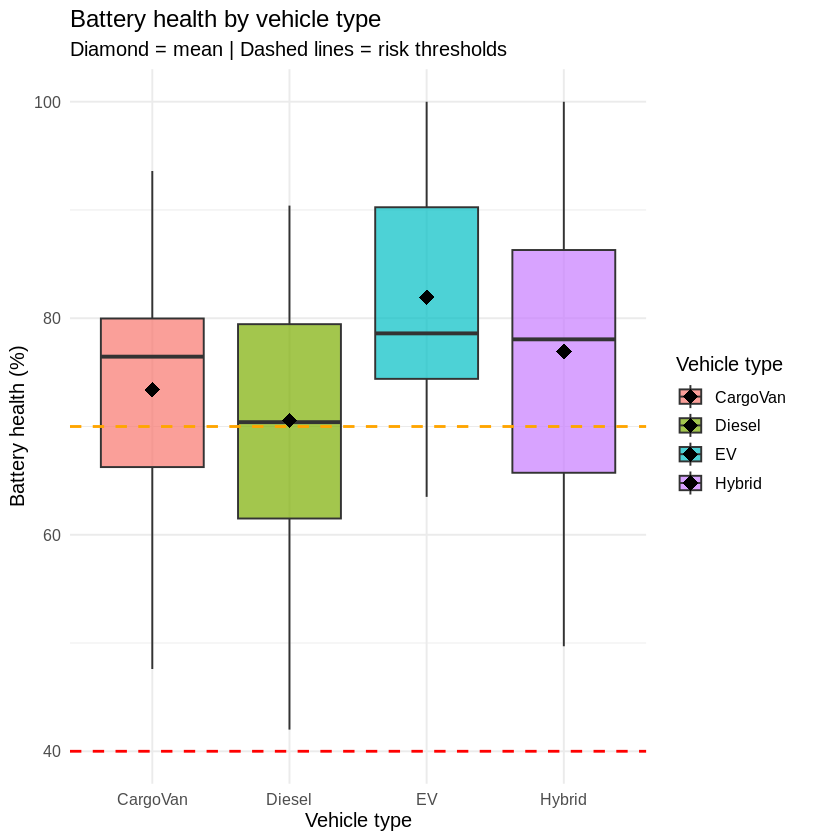

In [14]:
cat("\n── Analysis 3: Vehicle battery health ─────────────────────────────────\n")

risk_vec             <- cut(vehicles$battery_health_pct,
                            breaks = c(0, 40, 70, 100),
                            labels = c("High Risk (<40%)", "Medium Risk (40-70%)", "Healthy (>70%)"))
vehicles$battery_risk <- risk_vec

risk_table <- table(vehicles$battery_risk)
cat("Battery risk distribution:\n");   print(risk_table)
cat("\nPercentage breakdown:\n");       print(round(prop.table(risk_table) * 100, 1))
cat("\nMean battery health by type:\n"); print(round(tapply(vehicles$battery_health_pct, vehicles$vehicle_type, mean), 1))
cat("\nSD battery health by type:\n");   print(round(tapply(vehicles$battery_health_pct, vehicles$vehicle_type, sd), 2))

ev_battery     <- vehicles$battery_health_pct[vehicles$vehicle_type == "EV"]
non_ev_battery <- vehicles$battery_health_pct[vehicles$vehicle_type != "EV"]
t_result       <- t.test(ev_battery, non_ev_battery)
cat("\nT-test — EV vs non-EV battery health:\n"); print(t_result)

ggplot(vehicles, aes(x = battery_health_pct, fill = battery_risk)) +
  geom_histogram(binwidth = 5, colour = "white", alpha = 0.85) +
  geom_vline(xintercept = 40, linetype = "dashed", colour = "red",    linewidth = 1) +
  geom_vline(xintercept = 70, linetype = "dashed", colour = "orange", linewidth = 1) +
  scale_fill_manual(values = c("High Risk (<40%)"    = "#E24B4A",
                               "Medium Risk (40-70%)" = "#EF9F27",
                               "Healthy (>70%)"       = "#1D9E75")) +
  labs(title    = "Vehicle battery health distribution",
       subtitle = "Red dashed = high risk (40%) | Orange = medium risk (70%)",
       x = "Battery health (%)", y = "Number of vehicles", fill = "Risk category") +
  theme_minimal(base_size = 12)

ggplot(vehicles, aes(x = vehicle_type, y = battery_health_pct, fill = vehicle_type)) +
  geom_boxplot(alpha = 0.7, outlier.colour = "red", outlier.size = 2) +
  stat_summary(fun = mean, geom = "point", shape = 18, size = 4, colour = "black") +
  geom_hline(yintercept = 40, linetype = "dashed", colour = "red",    linewidth = 0.8) +
  geom_hline(yintercept = 70, linetype = "dashed", colour = "orange", linewidth = 0.8) +
  labs(title    = "Battery health by vehicle type",
       subtitle = "Diamond = mean | Dashed lines = risk thresholds",
       x = "Vehicle type", y = "Battery health (%)", fill = "Vehicle type") +
  theme_minimal(base_size = 12)

cat("\nInterpretation:\n")
cat("prop.table() shows the percentage of fleet at each risk level.\n")
cat("If the t-test p < 0.05, EV vehicles have significantly different battery",
    "health — NorthStar needs a vehicle-type-specific maintenance policy.\n")



── Analysis 4: Incident breakdown and chi-square test ─────────────────
Total incidents:        280 
Mean resolution hours:  11.98 
Median resolution hrs:  11.5 
SD resolution hours:    7.51 

By type:

    AppSyncError     BatteryAlert   CustomerNoShow     ProofMissing 
              31               36               44               46 
  RouteDeviation   SafetyNearMiss TemperatureIssue     VehicleFault 
              43               14               29               37 

By severity:

Critical     High      Low   Medium 
      27       68       79      106 


Warning message in chisq.test(table(incidents$incident_type, incidents$severity)):
“Chi-squared approximation may be incorrect”



Chi-square test — incident type vs severity:

	Pearson's Chi-squared test

data:  table(incidents$incident_type, incidents$severity)
X-squared = 17.001, df = 21, p-value = 0.711


Mean resolved hours by incident type:
    AppSyncError     BatteryAlert   CustomerNoShow     ProofMissing 
            12.5             11.7             13.8             10.9 
  RouteDeviation   SafetyNearMiss TemperatureIssue     VehicleFault 
            13.6              9.8             12.9              9.2 


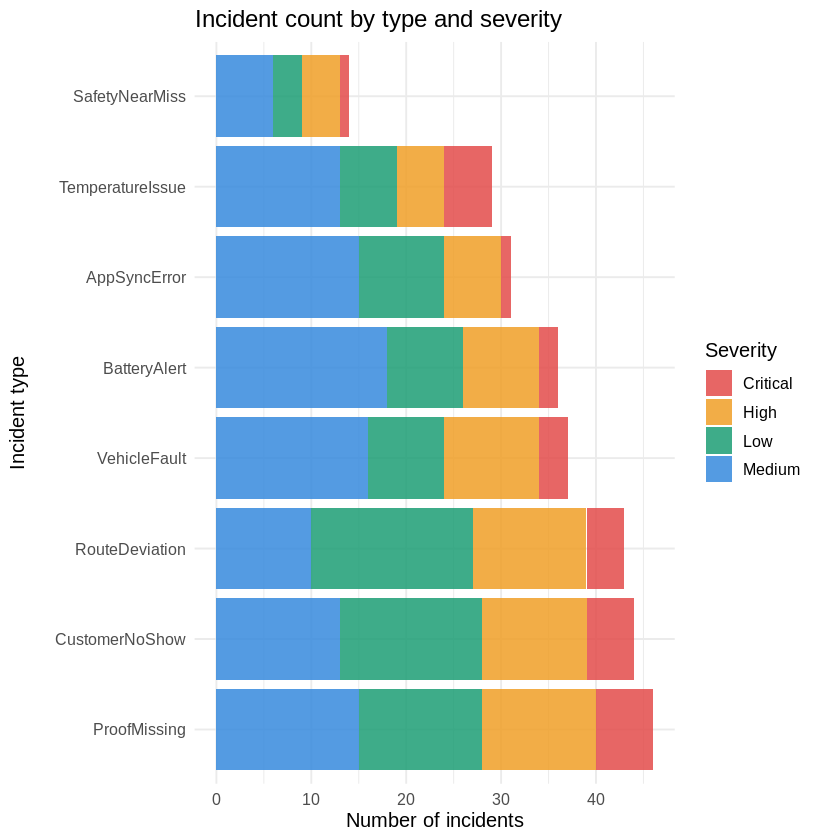


Interpretation:
Chi-square tests whether incident severity is independent of incident type.
p < 0.05 means certain incident types are significantly more likely to be Critical or High severity — guiding where NorthStar should focus prevention.


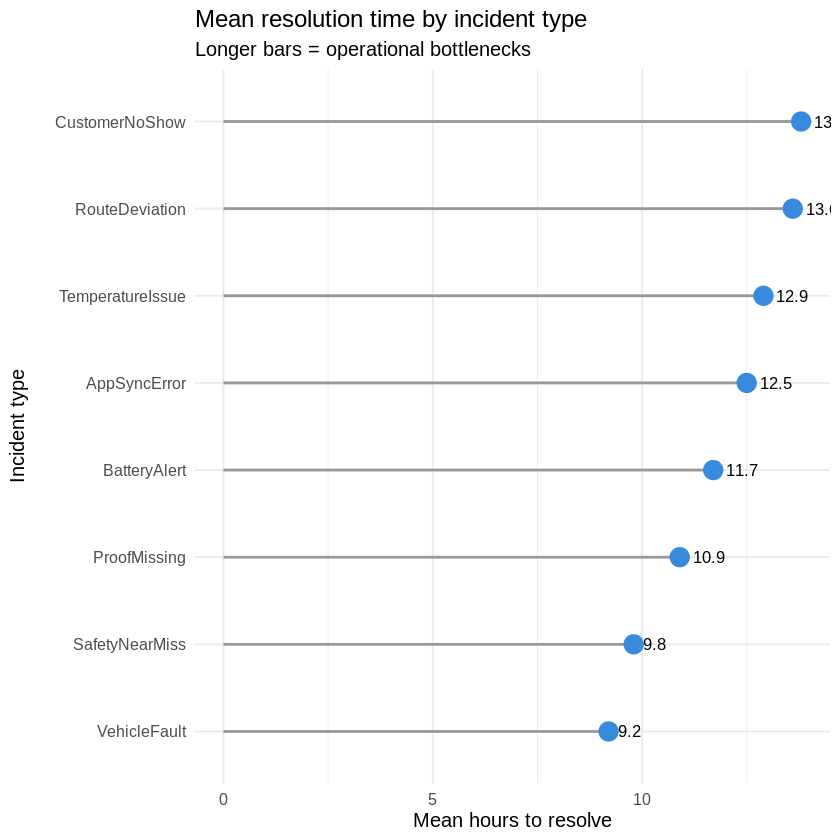

In [15]:
cat("\n── Analysis 4: Incident breakdown and chi-square test ─────────────────\n")

incident_list <- list(
  total        = nrow(incidents),
  by_type      = table(incidents$incident_type),
  by_severity  = table(incidents$severity),
  by_status    = table(incidents$resolution_status),
  avg_hours    = round(mean(incidents$resolved_hours), 2),
  median_hours = round(median(incidents$resolved_hours), 2),
  sd_hours     = round(sd(incidents$resolved_hours), 2)
)

cat("Total incidents:       ", incident_list$total, "\n")
cat("Mean resolution hours: ", incident_list$avg_hours, "\n")
cat("Median resolution hrs: ", incident_list$median_hours, "\n")
cat("SD resolution hours:   ", incident_list$sd_hours, "\n")
cat("\nBy type:\n");     print(incident_list$by_type)
cat("\nBy severity:\n"); print(incident_list$by_severity)

chi_result <- chisq.test(table(incidents$incident_type, incidents$severity))
cat("\nChi-square test — incident type vs severity:\n"); print(chi_result)

cat("\nMean resolved hours by incident type:\n")
print(round(tapply(incidents$resolved_hours, incidents$incident_type, mean), 1))

ggplot(incidents, aes(x = reorder(incident_type, incident_type, function(x) -length(x)),
                      fill = severity)) +
  geom_bar(alpha = 0.85) +
  scale_fill_manual(values = c("Critical" = "#E24B4A", "High" = "#EF9F27",
                               "Medium"   = "#378ADD", "Low"  = "#1D9E75")) +
  coord_flip() +
  labs(title = "Incident count by type and severity",
       x = "Incident type", y = "Number of incidents", fill = "Severity") +
  theme_minimal(base_size = 12)

res_means <- data.frame(
  type  = names(tapply(incidents$resolved_hours, incidents$incident_type, mean)),
  hours = round(tapply(incidents$resolved_hours, incidents$incident_type, mean), 1)
)
ggplot(res_means, aes(x = reorder(type, hours), y = hours)) +
  geom_segment(aes(xend = type, y = 0, yend = hours), colour = "grey60", linewidth = 0.8) +
  geom_point(size = 5, colour = "#378ADD") +
  geom_text(aes(label = hours), hjust = -0.4, size = 3.5) +
  coord_flip() +
  labs(title    = "Mean resolution time by incident type",
       subtitle = "Longer bars = operational bottlenecks",
       x = "Incident type", y = "Mean hours to resolve") +
  theme_minimal(base_size = 12)

cat("\nInterpretation:\n")
cat("Chi-square tests whether incident severity is independent of incident type.\n")
cat("p < 0.05 means certain incident types are significantly more likely to be",
    "Critical or High severity — guiding where NorthStar should focus prevention.\n")


── Analysis 5: ANOVA — resolution time by status ──────────────────────
Mean hours by status:
       Closed     Escalated          Open PendingVendor 
        11.50         13.09         12.82         11.00 

Median hours by status:
       Closed     Escalated          Open PendingVendor 
        11.50         12.10         11.80          9.65 

ANOVA summary:
                   Df Sum Sq Mean Sq F value Pr(>F)
resolution_status   3    169   56.44       1  0.393
Residuals         276  15576   56.44               

Tukey HSD post-hoc test:
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = resolved_hours ~ resolution_status, data = incidents)

$resolution_status
                              diff       lwr      upr     p adj
Escalated-Closed         1.5893677 -2.133972 5.312708 0.6877805
Open-Closed              1.3106664 -1.515502 4.136835 0.6281779
PendingVendor-Closed    -0.5092659 -3.868905 2.850373 0.9795551
Open-Escalated          -0.27

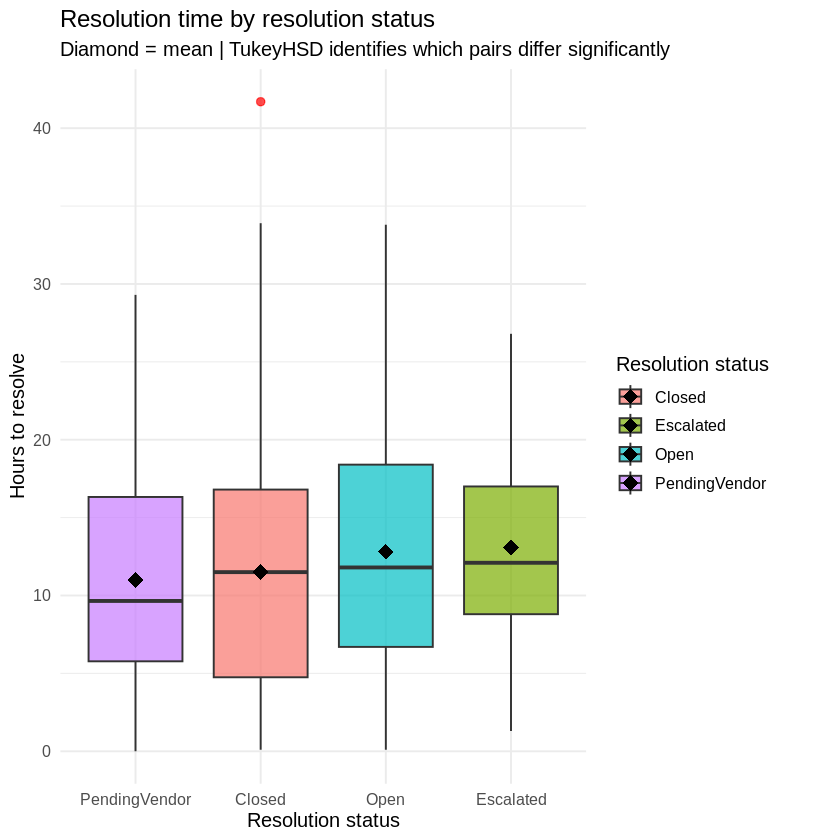

In [16]:
cat("\n── Analysis 5: ANOVA — resolution time by status ──────────────────────\n")

cat("Mean hours by status:\n")
print(round(tapply(incidents$resolved_hours, incidents$resolution_status, mean), 2))
cat("\nMedian hours by status:\n")
print(round(tapply(incidents$resolved_hours, incidents$resolution_status, median), 2))

anova_model <- aov(resolved_hours ~ resolution_status, data = incidents)
cat("\nANOVA summary:\n"); print(summary(anova_model))
cat("\nTukey HSD post-hoc test:\n"); print(TukeyHSD(anova_model))

ggplot(incidents, aes(x = reorder(resolution_status, resolved_hours, median),
                      y = resolved_hours, fill = resolution_status)) +
  geom_boxplot(alpha = 0.7, outlier.colour = "red", outlier.size = 2) +
  stat_summary(fun = mean, geom = "point", shape = 18, size = 4, colour = "black") +
  labs(title    = "Resolution time by resolution status",
       subtitle = "Diamond = mean | TukeyHSD identifies which pairs differ significantly",
       x = "Resolution status", y = "Hours to resolve", fill = "Resolution status") +
  theme_minimal(base_size = 12)

cat("\nInterpretation:\n")
cat("ANOVA tests if any group mean differs. TukeyHSD identifies exactly which",
    "pairs of statuses differ significantly.\n")
cat("If Escalated vs Closed p < 0.05, escalation causes measurable delays —",
    "a key finding for NorthStar's operational review.\n")


── Analysis 6: Driver rating vs incident rate ──────────────────────────
Pearson r = -0.002 | p = 0.94 

Linear regression summary:

Call:
lm(formula = incident_count ~ driver_rating + years_experience + 
    training_score, data = driver_inc)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.3495 -0.3017 -0.2795  0.6605  2.7660 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)
(Intercept)       0.2855322  0.2149801   1.328    0.184
driver_rating     0.0031410  0.0429449   0.073    0.942
years_experience -0.0065810  0.0045198  -1.456    0.146
training_score    0.0006768  0.0015492   0.437    0.662

Residual standard error: 0.5295 on 906 degrees of freedom
  (40 observations deleted due to missingness)
Multiple R-squared:  0.00239,	Adjusted R-squared:  -0.0009136 
F-statistic: 0.7234 on 3 and 906 DF,  p-value: 0.5381



`geom_smooth()` using formula = 'y ~ x'



Interpretation:
R-squared tells us how much variation in incidents is explained by driver-level factors vs external factors like route or vehicle.
Significant coefficients identify which characteristics NorthStar should prioritise in hiring and training decisions.


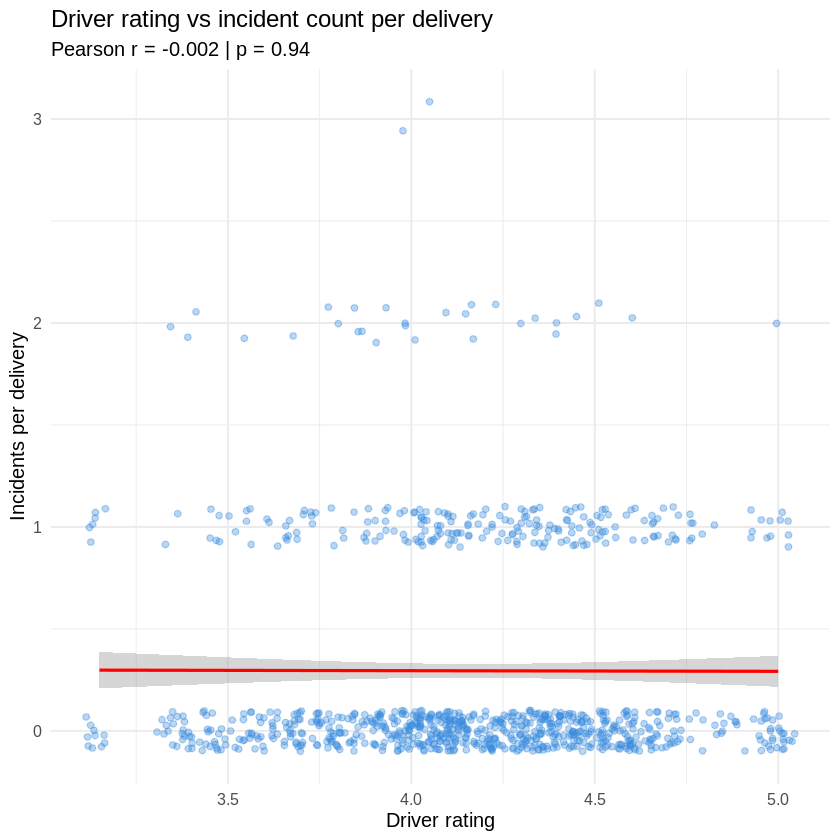

In [17]:
cat("\n── Analysis 6: Driver rating vs incident rate ──────────────────────────\n")

inc_counts  <- as.data.frame(table(incidents$delivery_id))
colnames(inc_counts) <- c("delivery_id", "incident_count")

driver_del <- merge(deliveries, drivers,    by = "driver_id",   all.x = TRUE)
driver_inc <- merge(driver_del, inc_counts, by = "delivery_id", all.x = TRUE)
driver_inc$incident_count[is.na(driver_inc$incident_count)] <- 0

cor_dr <- cor.test(driver_inc$driver_rating,
                   driver_inc$incident_count, method = "pearson")
cat("Pearson r =", round(cor_dr$estimate, 3),
    "| p =", round(cor_dr$p.value, 4), "\n")

lm_model <- lm(incident_count ~ driver_rating + years_experience + training_score,
               data = driver_inc)
cat("\nLinear regression summary:\n"); print(summary(lm_model))

ggplot(driver_inc, aes(x = driver_rating, y = incident_count)) +
  geom_jitter(alpha = 0.35, colour = "#378ADD", width = 0.05, height = 0.1, size = 1.5) +
  geom_smooth(method = "lm", se = TRUE, colour = "red", linewidth = 0.9) +
  labs(title    = "Driver rating vs incident count per delivery",
       subtitle = paste0("Pearson r = ", round(cor_dr$estimate, 3),
                         " | p = ", round(cor_dr$p.value, 4)),
       x = "Driver rating", y = "Incidents per delivery") +
  theme_minimal(base_size = 12)

cat("\nInterpretation:\n")
cat("R-squared tells us how much variation in incidents is explained by",
    "driver-level factors vs external factors like route or vehicle.\n")
cat("Significant coefficients identify which characteristics NorthStar should",
    "prioritise in hiring and training decisions.\n")


── Analysis 7: Delivery variable correlation matrix ───────────────────
First 5 rows of vehicle matrix:
     battery_health_pct odometer_km
[1,]              71.80       56928
[2,]              67.90      159368
[3,]              91.70      219359
[4,]              78.05       36310
[5,]              58.60      146638
Element [1,1]: 71.8 

Delivery correlation matrix:
                              route_distance_km manual_route_override_count
route_distance_km                         1.000                       0.199
manual_route_override_count               0.199                       1.000
fuel_or_charge_cost                       0.527                       0.099
customer_rating_post_delivery             0.029                      -0.060
                              fuel_or_charge_cost customer_rating_post_delivery
route_distance_km                           0.527                         0.029
manual_route_override_count                 0.099                        -0.060
fuel_or_

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggcorrplot package.
  Please report the issue at <https://github.com/kassambara/ggcorrplot/issues>.”



Interpretation:
Positive correlation between manual_route_override_count and fuel_or_charge_cost confirms overrides increase operating costs.
Negative correlation between customer_rating and override_count directly supports the concern that manual overrides harm service quality.


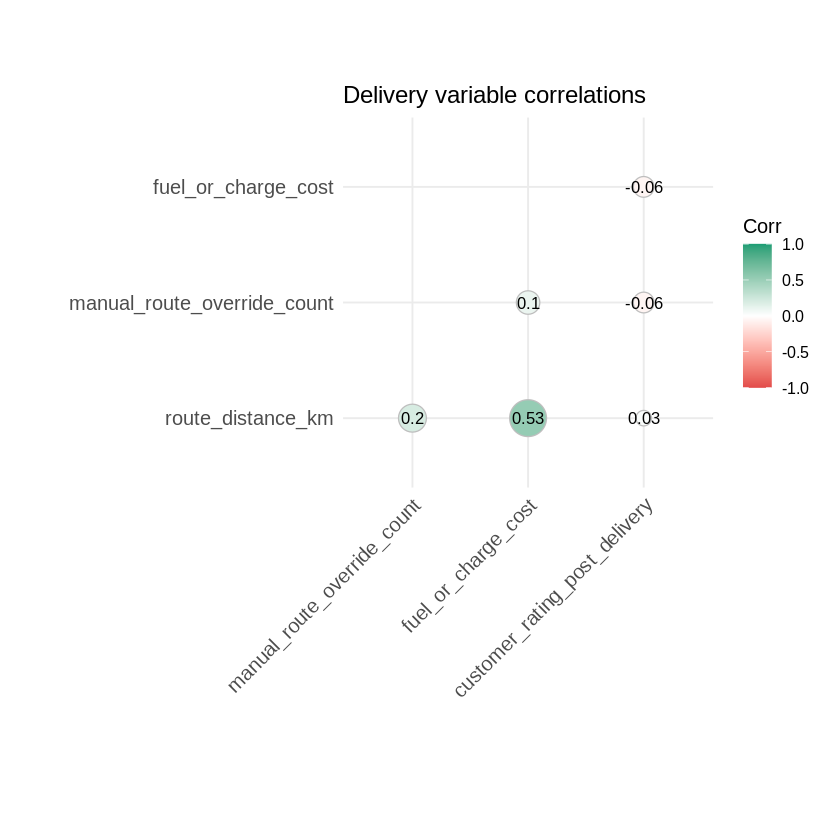

In [18]:
cat("\n── Analysis 7: Delivery variable correlation matrix ───────────────────\n")

vehicle_matrix <- matrix(
  c(vehicles$battery_health_pct, vehicles$odometer_km),
  ncol     = 2,
  dimnames = list(NULL, c("battery_health_pct", "odometer_km"))
)
cat("First 5 rows of vehicle matrix:\n"); print(vehicle_matrix[1:5, ])
cat("Element [1,1]:", vehicle_matrix[1, 1], "\n")

delivery_nums <- deliveries[, c("route_distance_km", "manual_route_override_count",
                                 "fuel_or_charge_cost", "customer_rating_post_delivery")]
delivery_nums <- delivery_nums[complete.cases(delivery_nums), ]
cor_mat       <- cor(delivery_nums, method = "pearson")
cat("\nDelivery correlation matrix:\n"); print(round(cor_mat, 3))

ggcorrplot(cor_mat, method = "circle", type = "lower", lab = TRUE, lab_size = 3.5,
           colors  = c("#E24B4A", "white", "#1D9E75"),
           title   = "Delivery variable correlations",
           ggtheme = theme_minimal(base_size = 12))

cat("\nInterpretation:\n")
cat("Positive correlation between manual_route_override_count and fuel_or_charge_cost",
    "confirms overrides increase operating costs.\n")
cat("Negative correlation between customer_rating and override_count directly supports",
    "the concern that manual overrides harm service quality.\n")



── Analysis 8: Customer loyalty and engagement ─────────────────────────
Loyalty score summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  13.10   49.00   59.60   59.69   70.45   99.00 

App engagement score summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00   45.23   58.95   58.17   72.10  100.00 

Customer count by type:

  Consumer Enterprise        SME 
       463         49        118 

Mean loyalty by home zone:
  Airport   Central      East     North Riverside     South      West 
     59.0      61.2      58.9      60.6      58.8      60.6      57.9 

Loyalty band counts:

   Low Medium   High 
    35    384    211 

Kruskal-Wallis test:

	Kruskal-Wallis rank sum test

data:  loyalty_score by customer_type
Kruskal-Wallis chi-squared = 3.0082, df = 2, p-value = 0.2222


Loyalty vs app engagement — r = 0.036 | p = 0.3715 


`geom_smooth()` using formula = 'y ~ x'


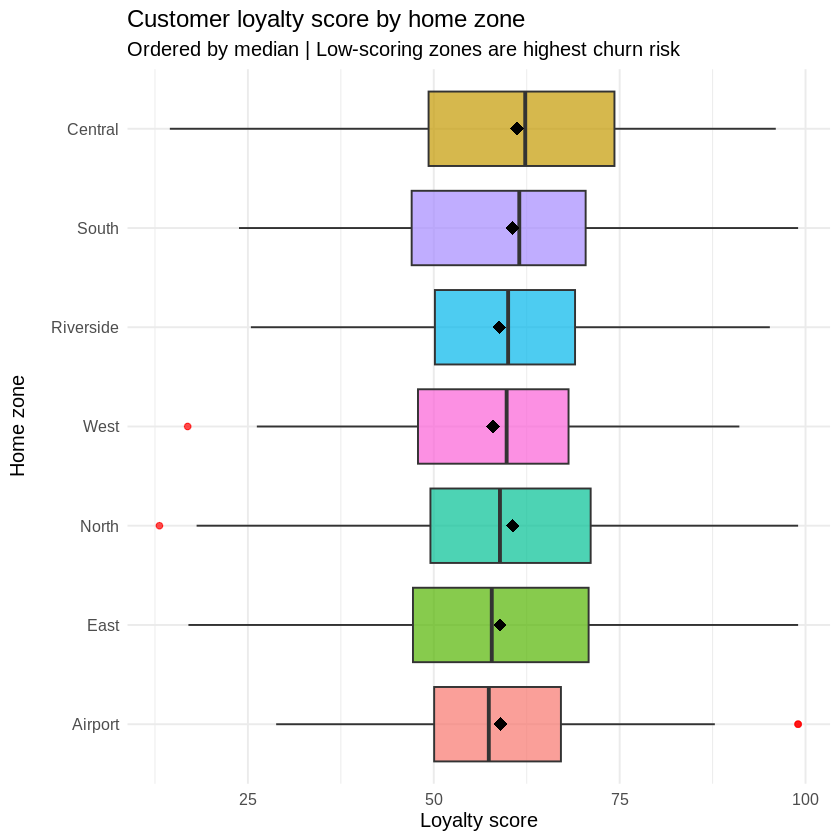

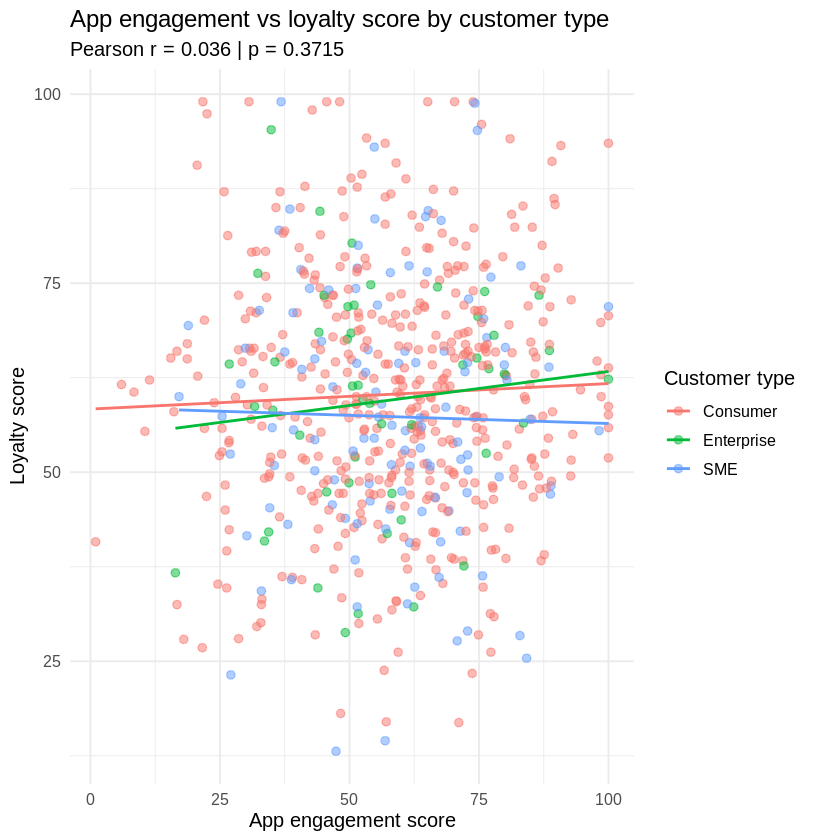


Interpretation:
Kruskal-Wallis is used instead of ANOVA because loyalty scores may not be normally distributed across customer types.
If p < 0.05, SME and Consumer customers have significantly different loyalty profiles — justifying separate retention strategies.
If app engagement correlates with loyalty (p < 0.05), improving the app directly drives customer retention for NorthStar.

=== R Analytics complete ===


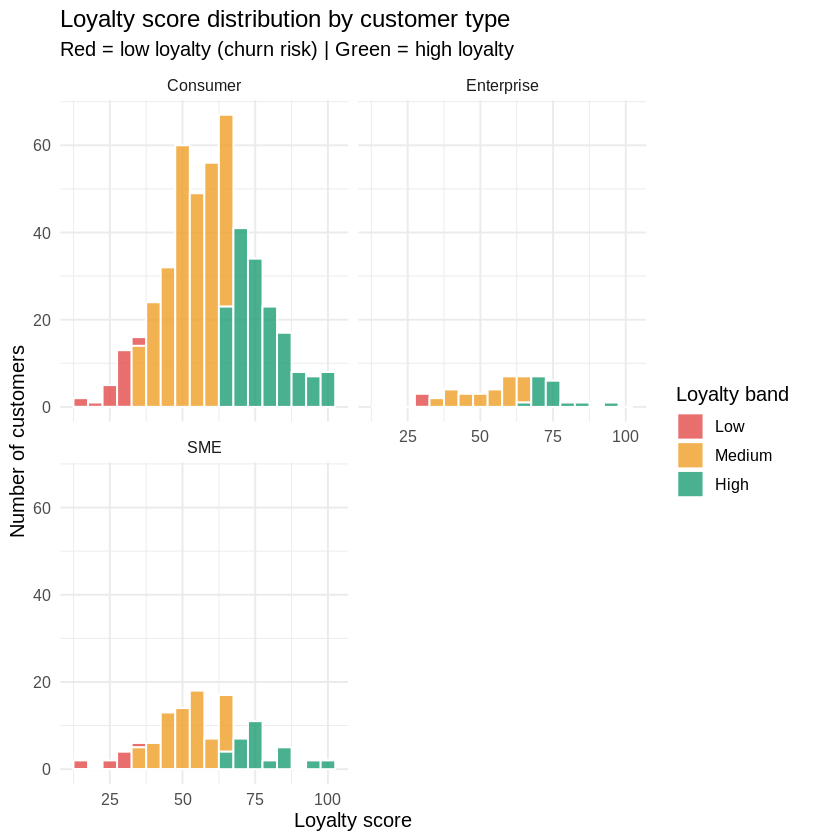

In [19]:
cat("\n── Analysis 8: Customer loyalty and engagement ─────────────────────────\n")

customers_clean <- customers[!is.na(customers$loyalty_score), ]

cat("Loyalty score summary:\n");         print(summary(customers_clean$loyalty_score))
cat("\nApp engagement score summary:\n"); print(summary(customers_clean$app_engagement_score))
cat("\nCustomer count by type:\n");       print(table(customers_clean$customer_type))

cat("\nMean loyalty by home zone:\n")
print(round(tapply(customers_clean$loyalty_score, customers_clean$home_zone, mean), 1))

customers_clean$loyalty_band <- cut(
  customers_clean$loyalty_score,
  breaks = c(0, 33, 66, 100),
  labels = c("Low", "Medium", "High")
)
cat("\nLoyalty band counts:\n"); print(table(customers_clean$loyalty_band))

kw_result     <- kruskal.test(loyalty_score ~ customer_type, data = customers_clean)
cat("\nKruskal-Wallis test:\n"); print(kw_result)

cor_loyal_eng <- cor.test(customers_clean$loyalty_score,
                          customers_clean$app_engagement_score, method = "pearson")
cat("\nLoyalty vs app engagement — r =", round(cor_loyal_eng$estimate, 3),
    "| p =", round(cor_loyal_eng$p.value, 4), "\n")

ggplot(customers_clean, aes(x = reorder(home_zone, loyalty_score, median),
                             y = loyalty_score, fill = home_zone)) +
  geom_boxplot(alpha = 0.7, outlier.colour = "red", outlier.size = 1.5) +
  stat_summary(fun = mean, geom = "point", shape = 18, size = 3.5, colour = "black") +
  coord_flip() +
  labs(title    = "Customer loyalty score by home zone",
       subtitle = "Ordered by median | Low-scoring zones are highest churn risk",
       x = "Home zone", y = "Loyalty score", fill = "Home zone") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none")

ggplot(customers_clean, aes(x = app_engagement_score, y = loyalty_score,
                             colour = customer_type)) +
  geom_point(alpha = 0.5, size = 2) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 0.8) +
  labs(title    = "App engagement vs loyalty score by customer type",
       subtitle = paste0("Pearson r = ", round(cor_loyal_eng$estimate, 3),
                         " | p = ", round(cor_loyal_eng$p.value, 4)),
       x = "App engagement score", y = "Loyalty score", colour = "Customer type") +
  theme_minimal(base_size = 12)

ggplot(customers_clean, aes(x = loyalty_score, fill = loyalty_band)) +
  geom_histogram(binwidth = 5, colour = "white", alpha = 0.8) +
  scale_fill_manual(values = c("Low" = "#E24B4A", "Medium" = "#EF9F27", "High" = "#1D9E75")) +
  facet_wrap(~ customer_type, ncol = 2) +
  labs(title    = "Loyalty score distribution by customer type",
       subtitle = "Red = low loyalty (churn risk) | Green = high loyalty",
       x = "Loyalty score", y = "Number of customers", fill = "Loyalty band") +
  theme_minimal(base_size = 12)

cat("\nInterpretation:\n")
cat("Kruskal-Wallis is used instead of ANOVA because loyalty scores may not be",
    "normally distributed across customer types.\n")
cat("If p < 0.05, SME and Consumer customers have significantly different loyalty",
    "profiles — justifying separate retention strategies.\n")
cat("If app engagement correlates with loyalty (p < 0.05), improving the app",
    "directly drives customer retention for NorthStar.\n")

cat("\n=== R Analytics complete ===\n")
